# Potato Leaf Disease Classification Using CNN

**Group members:**

- Saad Bin Zahid (24K-8046)
- Muhammad Owais (24K-8049)

Dataset credits: https://www.kaggle.com/arjuntejaswi/plant-village

### Import all the Dependencies

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

### Set all the Constants

In [ ]:
# Constants / hyperparameters
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

DATA_DIR = "PlantVillage"

CLASS_NAMES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
]


### Import data into tensorflow dataset object

In [ ]:
import os, zipfile

zip_path = "/content/PlantVillage - PotatoOnly.zip.zip"
extract_root = "/content/potato_data"
os.makedirs(extract_root, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_root)

# Auto-detect the folder that directly contains the 3 class folders
DATA_DIR = None
for root, dirs, files in os.walk(extract_root):
    if all(cls in dirs for cls in CLASS_NAMES):
        DATA_DIR = root
        break

print("DATA_DIR set to:", DATA_DIR)
print("Folders inside DATA_DIR:", os.listdir(DATA_DIR))

DATA_DIR set to: /content/potato_data/PlantVillage
Folders inside DATA_DIR: ['Tomato_Leaf_Mold', 'Potato___Late_blight', 'Tomato_healthy', 'Pepper__bell___Bacterial_spot', 'Tomato_Bacterial_spot', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Potato___healthy']


In [ ]:
dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    class_names=CLASS_NAMES,
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [ ]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [ ]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 256, 256, 3)
[1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 2 0 0]


As you can see above, each element in the dataset is a tuple. First element is a batch of 32 elements of images. Second element is a batch of 32 elements of class labels

### Visualize some of the images from our dataset

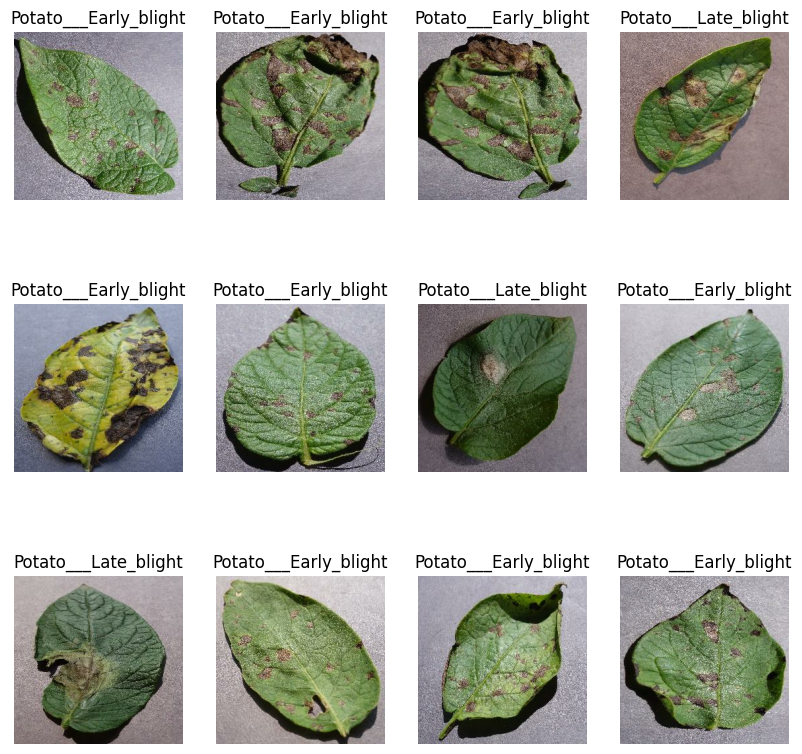

In [ ]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

### Function to Split Dataset

Dataset should be bifurcated into 3 subsets, namely:
1. Training: Dataset to be used while training
2. Validation: Dataset to be tested against while training
3. Test: Dataset to be tested against after we trained a model

In [ ]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [ ]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [ ]:
len(train_ds)

54

In [ ]:
len(val_ds)

6

In [ ]:
len(test_ds)

8

### Cache, Shuffle, and Prefetch the Dataset

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Building the Model

### Creating a Layer for Resizing and Normalization
Before we feed our images to network, we should be resizing it to the desired size.
Moreover, to improve model performance, we should normalize the image pixel value (keeping them in range 0 and 1 by dividing by 256).
This should happen while training as well as inference. Hence we can add that as a layer in our Sequential Model.


In [ ]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])


### Data Augmentation
Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])


#### Applying Data Augmentation to Train Dataset

In [ ]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)



### Model Architecture
We use a CNN coupled with a Softmax activation in the output layer. We also add the initial layers for resizing, normalization and Data Augmentation.

In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

# ─────────────────────────────────────────────────────────────────────
# FIX: use tf.keras.Input() instead of input_shape= inside Conv2D
# ─────────────────────────────────────────────────────────────────────
# The original code passed input_shape= as a keyword argument to the
# first Conv2D layer.  Keras creates a hidden InputLayer internally
# but does NOT register it as a named node in the computation graph.
# Because of this, model.summary() shows every output shape as 'None'
# and parameter counts are blank — shape inference is deferred until
# the first forward pass.
#
# Switching to an explicit tf.keras.Input() as the very first layer
# forces Keras to trace the full graph at definition time, so
# model.summary() immediately shows correct output shapes and
# parameter counts for every layer.
# ─────────────────────────────────────────────────────────────────────

inputs = tf.keras.Input(shape=input_shape, name='input_layer')

# Resize + rescale block
x = resize_and_rescale(inputs)

# Conv blocks
x = layers.Conv2D(32, kernel_size=(3, 3), activation='relu', name='conv1')(x)
x = layers.MaxPooling2D((2, 2), name='pool1')(x)
x = layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv2')(x)
x = layers.MaxPooling2D((2, 2), name='pool2')(x)
x = layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv3')(x)
x = layers.MaxPooling2D((2, 2), name='pool3')(x)
x = layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv4')(x)
x = layers.MaxPooling2D((2, 2), name='pool4')(x)
x = layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv5')(x)
x = layers.MaxPooling2D((2, 2), name='pool5')(x)
x = layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv6')(x)
x = layers.MaxPooling2D((2, 2), name='pool6')(x)

# Dense head
x = layers.Flatten(name='flatten')(x)
x = layers.Dense(64, activation='relu', name='dense1')(x)
outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name='potato_cnn')

# Now summary correctly shows all output shapes and parameter counts
model.summary()

Model: "potato_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool6 (MaxPooling2D)            │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model
We use `adam` Optimizer, `SparseCategoricalCrossentropy` for losses, `accuracy` as a metric

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=50,
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 440ms/step - accuracy: 0.4965 - loss: 0.9184 - val_accuracy: 0.6354 - val_loss: 0.8600
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 364ms/step - accuracy: 0.6788 - loss: 0.6847 - val_accuracy: 0.6823 - val_loss: 0.7298
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 365ms/step - accuracy: 0.8403 - loss: 0.3985 - val_accuracy: 0.8333 - val_loss: 0.3804
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 401ms/step - accuracy: 0.8854 - loss: 0.2923 - val_accuracy: 0.8646 - val_loss: 0.3025
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 363ms/step - accuracy: 0.9178 - loss: 0.2055 - val_accuracy: 0.9062 - val_loss: 0.1829
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 380ms/step - accuracy: 0.9259 - loss: 0.1758 - val_accuracy: 0.9531 - val_loss: 0.1110
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 376ms/step - accuracy: 0.9537 - loss: 0.1197 - val_accuracy: 0.9271 - val_loss: 0.1831
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 365ms/step - accuracy: 0.9439 - loss: 0.1519 - val_accu

**Test performance is reported below using accuracy, per-class metrics, and a confusion matrix.**

In [ ]:
scores = model.evaluate(test_ds)
print("Test Loss:", scores[0])
print("Test Accuracy:", scores[1])

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9727 - loss: 0.0750
Test Loss: 0.07504360377788544
Test Accuracy: 0.97265625


                       precision    recall  f1-score   support

Potato___Early_blight       0.98      1.00      0.99       110
 Potato___Late_blight       0.99      0.95      0.97       128
     Potato___healthy       0.81      0.94      0.87        18

             accuracy                           0.97       256
            macro avg       0.93      0.97      0.94       256
         weighted avg       0.97      0.97      0.97       256



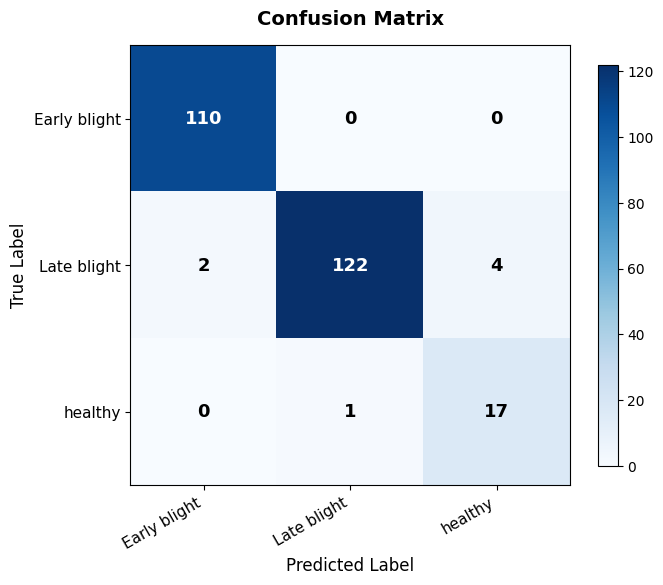

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    probs = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(y_batch.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

# Shorter labels for readability
short_names = [c.replace("Potato___", "").replace("_", " ") for c in class_names]
# Gives: ['Early Blight', 'Late Blight', 'Healthy']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, shrink=0.85)

tick_marks = np.arange(len(class_names))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(short_names, rotation=30, ha="right", fontsize=11)
ax.set_yticklabels(short_names, fontsize=11)

# White text on dark cells, black text on light cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center", fontsize=13, fontweight='bold',
                color="white" if cm[i, j] > thresh else "black")

ax.set_title("Confusion Matrix", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Plotting the Accuracy and Loss Curves

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

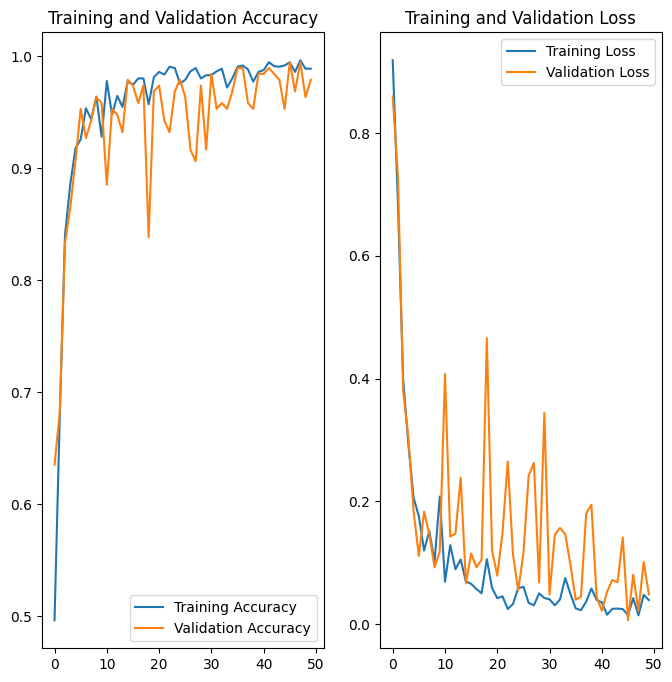

In [ ]:
epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Running prediction on a sample image

first image to predict
actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
predicted label: Potato___Early_blight


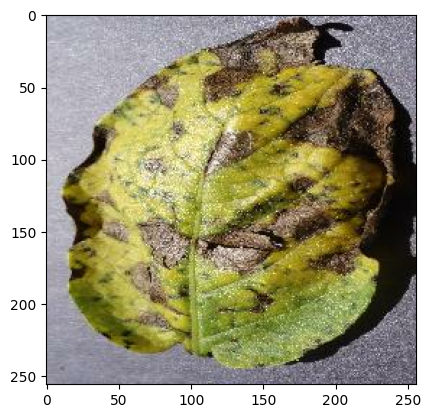

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

### Writing a function for inference

In [ ]:
def predict(model, img):
    img_batch = tf.expand_dims(tf.cast(img, tf.float32), axis=0)
    preds = model.predict(img_batch, verbose=0)
    predicted_class = class_names[int(np.argmax(preds[0]))]
    confidence = round(100 * float(np.max(preds[0])), 2)
    return predicted_class, confidence

**Now running inference on few sample images**

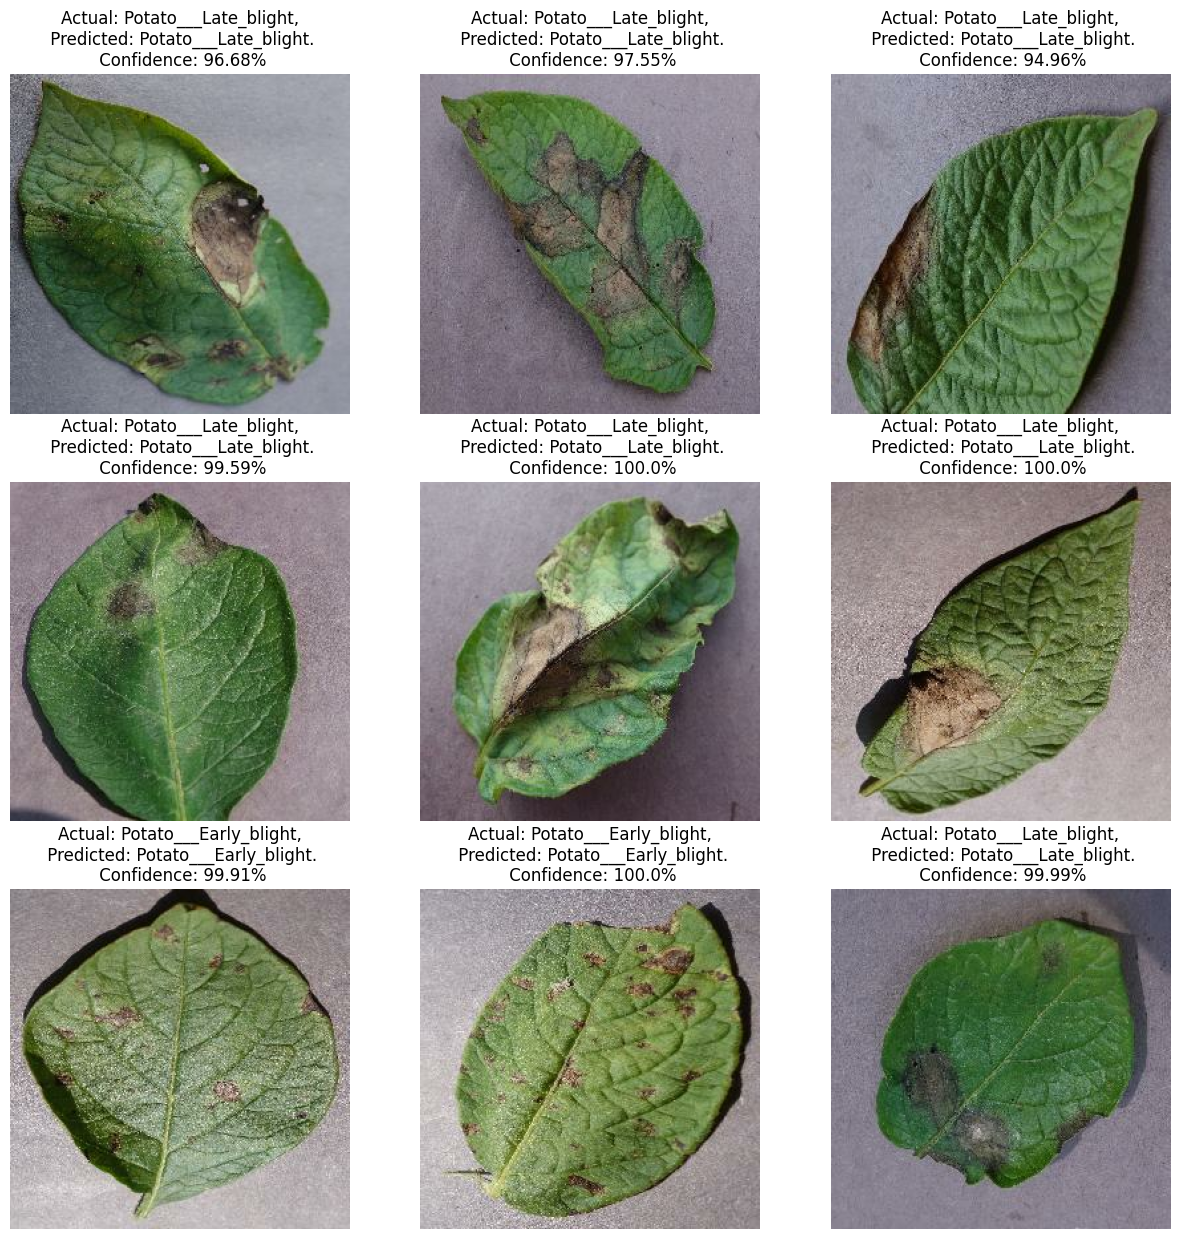

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

### Saving the Model

In [ ]:
model.save("/content/potato_disease_cnn.keras")